# Load Data

In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("48-us_births_2016_2021.csv")

In [3]:
df.head()

,State,State Abbreviation,Year,Gender,Education Level of Mother,Education Level Code,Number of Births,Average Age of Mother (years),Average Birth Weight (g)
0,Alabama,AL,2016,F,8th grade or less,1,1052,27.8,3116.9
1,Alabama,AL,2016,F,9th through 12th grade with no diploma,2,3436,24.1,3040.0
2,Alabama,AL,2016,F,High school graduate or GED completed,3,8777,25.4,3080.0
3,Alabama,AL,2016,F,"Some college credit, but not a degree",4,6453,26.7,3121.9
4,Alabama,AL,2016,F,"Associate degree (AA, AS)",5,2227,28.9,3174.3


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5496 entries, 0 to 5495
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   State                          5496 non-null   object 
 1   State Abbreviation             5496 non-null   object 
 2   Year                           5496 non-null   int64  
 3   Gender                         5496 non-null   object 
 4   Education Level of Mother      5496 non-null   object 
 5   Education Level Code           5496 non-null   int64  
 6   Number of Births               5496 non-null   int64  
 7   Average Age of Mother (years)  5496 non-null   float64
 8   Average Birth Weight (g)       5496 non-null   float64
dtypes: float64(2), int64(3), object(4)
memory usage: 386.6+ KB


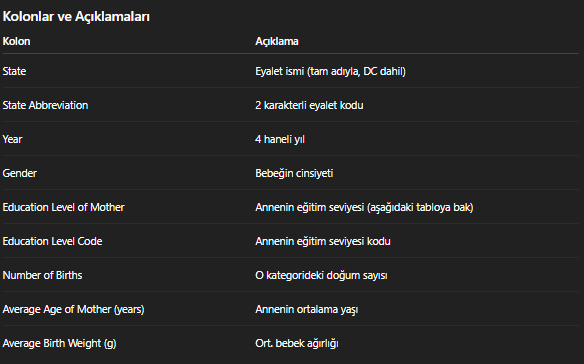

In [5]:
df.isnull().sum()

State                            0
State Abbreviation               0
Year                             0
Gender                           0
Education Level of Mother        0
Education Level Code             0
Number of Births                 0
Average Age of Mother (years)    0
Average Birth Weight (g)         0
dtype: int64

In [6]:
df.duplicated().sum()

0

# EDA

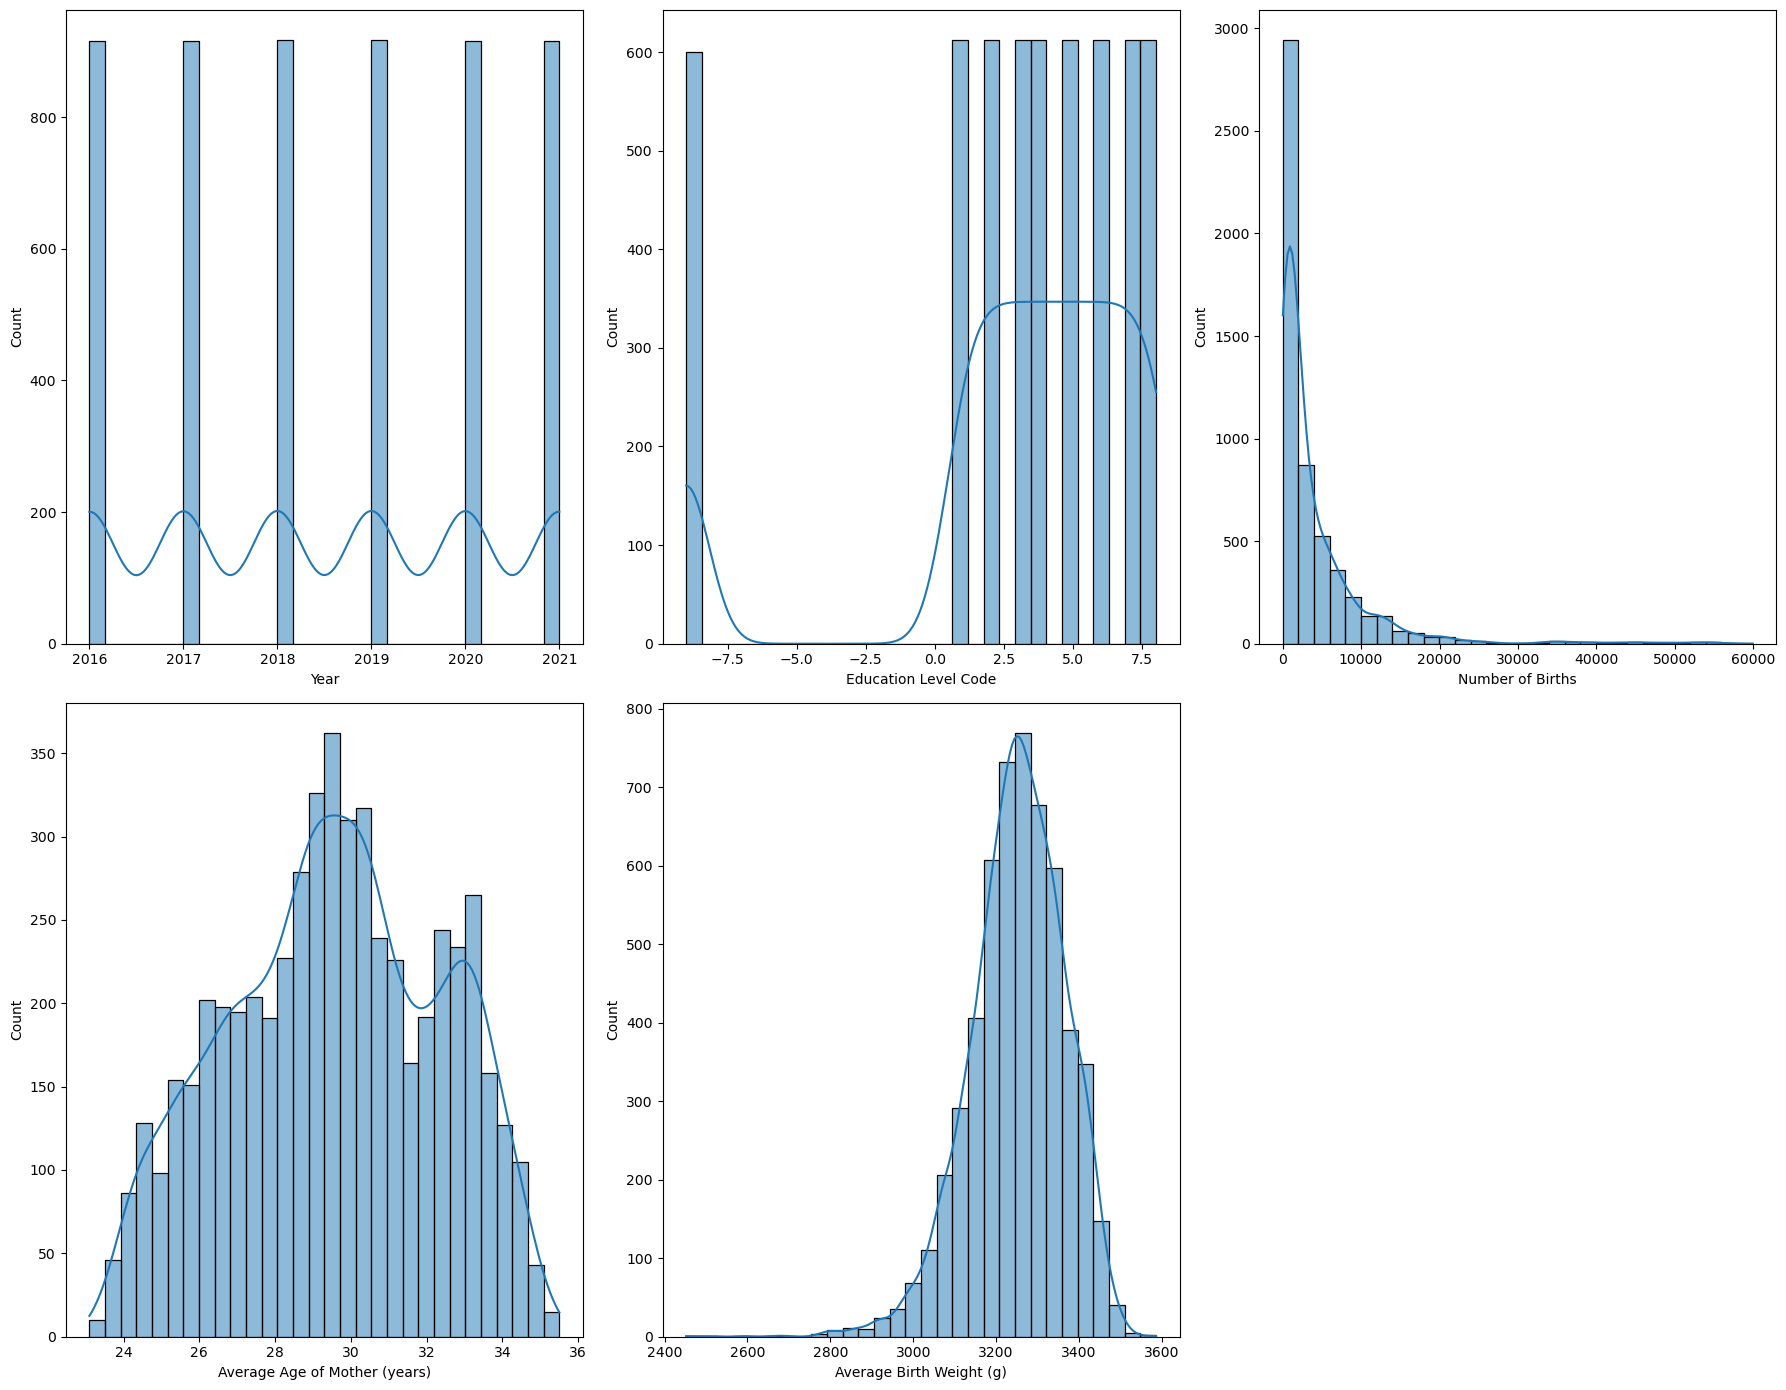

In [7]:
num_cols = [col for col in df.columns if df[col].dtype != 'O']

n_cols = 3
n_rows = int(len(num_cols) / n_cols) + 1

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, 7*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df, x=col, kde=True, bins=30, ax=axes[i])

for j in range (i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [8]:
df['Education Level Code'].value_counts()

Education Level Code
 1    612
 2    612
 3    612
 4    612
 5    612
 6    612
 7    612
 8    612
-9    600
Name: count, dtype: int64

In [9]:
df['Education Level of Mother'].value_counts()

Education Level of Mother
8th grade or less                                                      612
9th through 12th grade with no diploma                                 612
High school graduate or GED completed                                  612
Some college credit, but not a degree                                  612
Associate degree (AA, AS)                                              612
Bachelor's degree (BA, AB, BS)                                         612
Master's degree (MA, MS, MEng, MEd, MSW, MBA)                          612
Doctorate (PhD, EdD) or Professional Degree (MD, DDS, DVM, LLB, JD)    612
Unknown or Not Stated                                                  600
Name: count, dtype: int64

- Bu ikisi aynı manaya geliyor. O yüzden birini drop edeceğim.

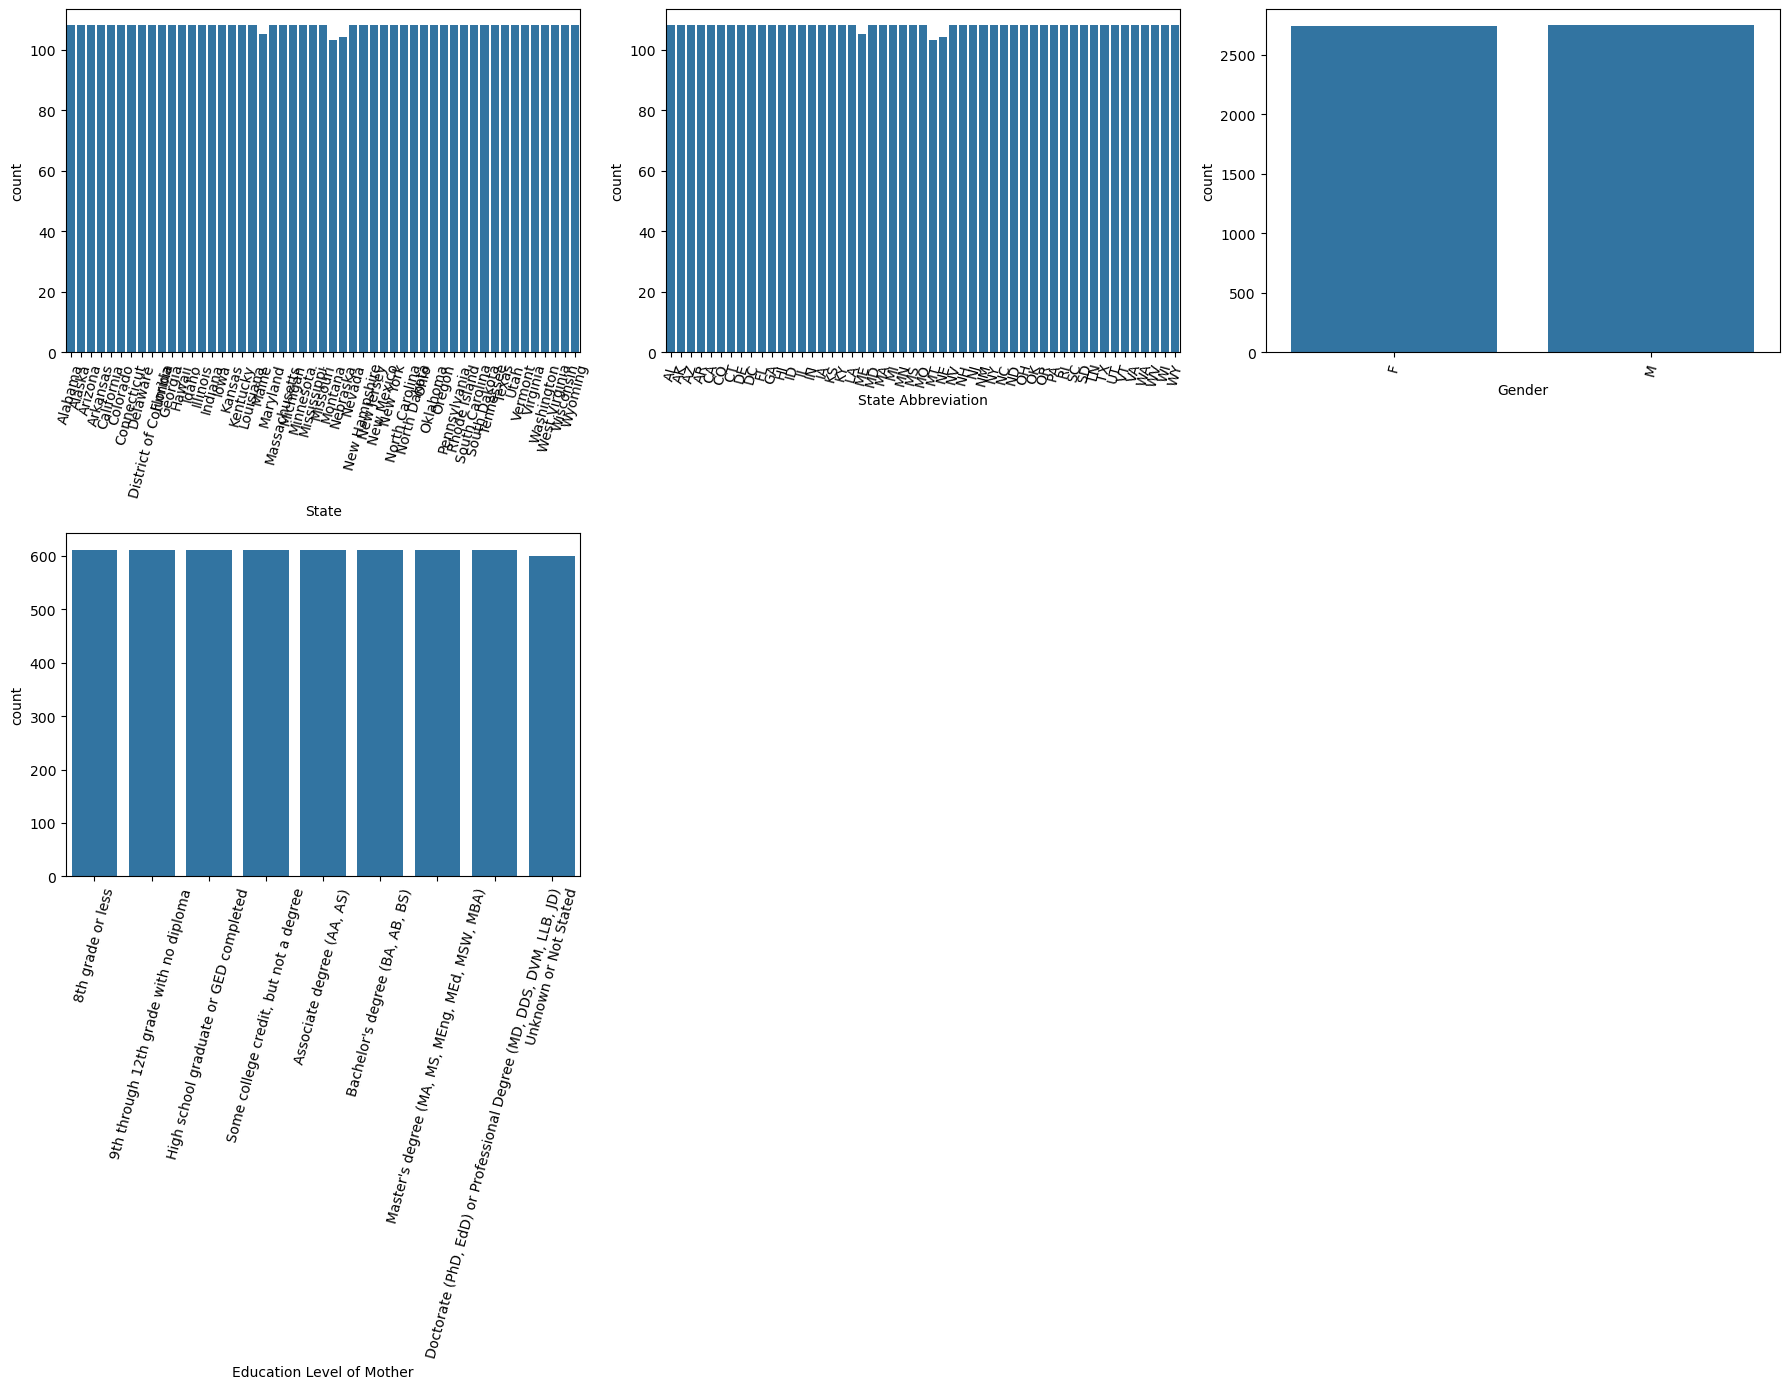

In [10]:
cat_cols = [col for col in df.columns if df[col].dtype == 'O']

n_cols = 3
n_rows = int(len(cat_cols) / n_cols) + 1

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, 7*n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(df, x=col,ax=axes[i],)
    axes[i].tick_params(axis='x', rotation=75)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

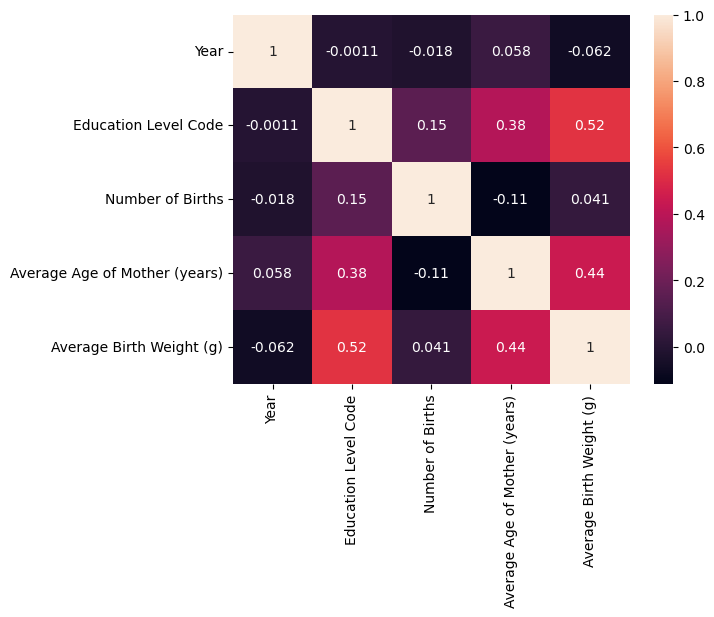

In [11]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

# Data Cleaning and Encoding

In [12]:
df.drop(columns=['Education Level Code'], inplace=True)

In [13]:
df.drop(columns=['State Abbreviation'], inplace=True)

In [14]:
df.head()

,State,Year,Gender,Education Level of Mother,Number of Births,Average Age of Mother (years),Average Birth Weight (g)
0,Alabama,2016,F,8th grade or less,1052,27.8,3116.9
1,Alabama,2016,F,9th through 12th grade with no diploma,3436,24.1,3040.0
2,Alabama,2016,F,High school graduate or GED completed,8777,25.4,3080.0
3,Alabama,2016,F,"Some college credit, but not a degree",6453,26.7,3121.9
4,Alabama,2016,F,"Associate degree (AA, AS)",2227,28.9,3174.3


In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X = df.drop('Average Birth Weight (g)', axis=1)
y = df['Average Birth Weight (g)']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=36)

In [18]:
# Target encoding manuel
birt_mean_weight = X_train.join(y_train).groupby("State")["Average Birth Weight (g)"].mean().to_dict()

X_train["State_target"] = X_train["State"].map(birt_mean_weight)
X_test["State_target"] = X_test["State"].map(birt_mean_weight)

# Test sette bilinmeyen state olursa global ortalama ile doldur
global_mean = X_train["State_target"].mean()
X_test["State_target"] = X_test["State_target"].fillna(global_mean)

# Orijinal State kolonunu çıkar
X_train.drop("State", axis=1, inplace=True)
X_test.drop("State", axis=1, inplace=True)

In [19]:
X_train.head()

,Year,Gender,Education Level of Mother,Number of Births,Average Age of Mother (years),State_target
4514,2021,F,Unknown or Not Stated,17,28.6,3298.034524
89,2020,M,Unknown or Not Stated,37,30.6,3196.061905
5446,2019,F,"Associate degree (AA, AS)",389,29.3,3164.747059
5403,2016,M,"Master's degree (MA, MS, MEng, MEd, MSW, MBA)",286,32.2,3164.747059
2327,2019,F,Unknown or Not Stated,887,31.4,3267.856098


In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [21]:
transformer = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'), ['Education Level of Mother', 'Gender'])
    ], remainder='passthrough'
)

In [22]:
X_train = transformer.fit_transform(X_train)
X_test = transformer.transform(X_test)

In [23]:
col_names = transformer.get_feature_names_out()

In [24]:
X_train = pd.DataFrame(data=X_train, columns=col_names)
X_test = pd.DataFrame(data=X_test, columns=col_names)

In [25]:
X_train.head()

,onehot__Education Level of Mother_9th through 12th grade with no diploma,"onehot__Education Level of Mother_Associate degree (AA, AS)","onehot__Education Level of Mother_Bachelor's degree (BA, AB, BS)","onehot__Education Level of Mother_Doctorate (PhD, EdD) or Professional Degree (MD, DDS, DVM, LLB, JD)",onehot__Education Level of Mother_High school graduate or GED completed,"onehot__Education Level of Mother_Master's degree (MA, MS, MEng, MEd, MSW, MBA)","onehot__Education Level of Mother_Some college credit, but not a degree",onehot__Education Level of Mother_Unknown or Not Stated,onehot__Gender_M,remainder__Year,remainder__Number of Births,remainder__Average Age of Mother (years),remainder__State_target
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2021.0,17.0,28.6,3298.034524
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2020.0,37.0,30.6,3196.061905
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2019.0,389.0,29.3,3164.747059
3,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,2016.0,286.0,32.2,3164.747059
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2019.0,887.0,31.4,3267.856098


In [26]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4122 entries, 0 to 4121
Data columns (total 13 columns):
 #   Column                                                                                                 Non-Null Count  Dtype  
---  ------                                                                                                 --------------  -----  
 0   onehot__Education Level of Mother_9th through 12th grade with no diploma                               4122 non-null   float64
 1   onehot__Education Level of Mother_Associate degree (AA, AS)                                            4122 non-null   float64
 2   onehot__Education Level of Mother_Bachelor's degree (BA, AB, BS)                                       4122 non-null   float64
 3   onehot__Education Level of Mother_Doctorate (PhD, EdD) or Professional Degree (MD, DDS, DVM, LLB, JD)  4122 non-null   float64
 4   onehot__Education Level of Mother_High school graduate or GED completed                         

# Model Training

In [27]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(true, pred):
    print("Mean Absolute Error:", mean_absolute_error(true,pred))
    print("Root Mean Squared Error:", np.sqrt(mean_squared_error(true,pred)))
    print("R2:", r2_score(true,pred))

In [29]:
models = {
    'Linear Regression' : LinearRegression(),
    'Ridge' : Ridge(),
    'Lasso' : Lasso(),
    'Elastic Net' : ElasticNet(),
    'SVR' : SVR(),
    'KNN' : KNeighborsRegressor(),
    'Decision Tree Regressor' : DecisionTreeRegressor(),
    'Random Forest Regressor' : RandomForestRegressor(),
    'Adaboost Regressor' : AdaBoostRegressor(),
    'GradientBoost Regressor' : GradientBoostingRegressor(),
    'XGBoost Regressor' : XGBRegressor(),
    #'LightGBM Regressor' : LGBMRegressor()
}

In [30]:
for col in range(len(list(models))):
    model = list(models.values())[col]
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    print(list(models.keys())[col], "result for train data set:")
    evaluate(y_train, y_pred_train)
    print("\n")
    print(list(models.keys())[col], "result for test data set:")
    evaluate(y_test, y_pred_test)
    print("----------------------------------------------------------")

Linear Regression result for train data set:
Mean Absolute Error: 33.69330061096448
Root Mean Squared Error: 52.60372720688213
R2: 0.7932546049286612


Linear Regression result for test data set:
Mean Absolute Error: 32.95996597194618
Root Mean Squared Error: 48.3261056901073
R2: 0.809144376188685
----------------------------------------------------------
Ridge result for train data set:
Mean Absolute Error: 33.70054755357979
Root Mean Squared Error: 52.604335610408086
R2: 0.7932498225544298


Ridge result for test data set:
Mean Absolute Error: 32.96681176533723
Root Mean Squared Error: 48.332934673124406
R2: 0.8090904325951105
----------------------------------------------------------
Lasso result for train data set:
Mean Absolute Error: 35.15800929617911
Root Mean Squared Error: 53.6176898275804
R2: 0.7852075521969776


Lasso result for test data set:
Mean Absolute Error: 34.67152082966006
Root Mean Squared Error: 49.86285962116955
R2: 0.7968130899440695
----------------------------

# Hyperparameter Tuning

In [32]:
from sklearn.model_selection import RandomizedSearchCV

In [33]:
params_randomForest = {
    'n_estimators' : [100, 200, 300, 500,],
    'criterion' : ['squared_error', 'absolute_error', 'friedman_mse', 'poisson'],
    'max_depth' : [None, 3 ,5 ,7, 10, 20, 30],
    'min_samples_split' : [2, 3, 5, 10],
    'min_samples_leaf' : [1, 2, 3, 5, 10]
}

params_gradientBoosting = {
    'loss' : ['squared_error', 'absolute_error', 'huber', 'quantile'],
    'learning_rate' : [0.1, 0.05, 1],
    'n_estimators' : [100, 200, 300, 500,],
    'subsample' : [0.2, 0.5, 1.0],
    'max_depth' : [None, 3 ,5 ,7, 10, 20, 30],
    'criterion' : ['squared_error', 'friedman_mse']
}

params_xgboost = {
    'learning_rate' : [0.1, 0.05, 1],
    'max_depth' : [None, 3 ,5 ,7, 10, 20, 30],
    'min_split_loss' : [0, 1, 2, 3, 5, 10],
    'subsample' : [0.2, 0.5, 1.0],
    'colsample_bytree' : [0.2, 0.5, 0.8, 1.0],
    'reg_lambda' : [0, 0.5, 1.0, 1.5],
    'reg_alpha' : [0, 0.5, 1.0, 1.5]
}

In [34]:
randomForest = RandomizedSearchCV(
    estimator=RandomForestRegressor(),
    param_distributions=params_randomForest,
    cv=5,
    n_jobs=-1,
    verbose = 3
)
randomForest.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(), n_jobs=-1,
                   param_distributions={'criterion': ['squared_error',
                                                      'absolute_error',
                                                      'friedman_mse',
                                                      'poisson'],
                                        'max_depth': [None, 3, 5, 7, 10, 20,
                                                      30],
                                        'min_samples_leaf': [1, 2, 3, 5, 10],
                                        'min_samples_split': [2, 3, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   verbose=3)

In [35]:
y_pred = randomForest.predict(X_test)
evaluate(y_test, y_pred)

Mean Absolute Error: 26.177680494905424
Root Mean Squared Error: 46.30261073458977
R2: 0.8247926500476295


In [36]:
gradientBoost = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(),
    param_distributions=params_gradientBoosting,
    cv=5,
    n_jobs=-1,
    verbose = 3
)
gradientBoost.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5, estimator=GradientBoostingRegressor(), n_jobs=-1,
                   param_distributions={'criterion': ['squared_error',
                                                      'friedman_mse'],
                                        'learning_rate': [0.1, 0.05, 1],
                                        'loss': ['squared_error',
                                                 'absolute_error', 'huber',
                                                 'quantile'],
                                        'max_depth': [None, 3, 5, 7, 10, 20,
                                                      30],
                                        'n_estimators': [100, 200, 300, 500],
                                        'subsample': [0.2, 0.5, 1.0]},
                   verbose=3)

In [37]:
y_pred = gradientBoost.predict(X_test)
evaluate(y_test, y_pred)

Mean Absolute Error: 25.765930005860877
Root Mean Squared Error: 46.376254982592314
R2: 0.8242348726592349


In [38]:
xgboost = RandomizedSearchCV(
    estimator=XGBRegressor(),
    param_distributions=params_xgboost,
    cv=5,
    n_jobs=-1,
    verbose = 3
)
xgboost.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.2, 0.5, 0.8,
                                                             1.0],
                                        'learning_rate': [0.1, 0.05, 1],
                                        'max_depth': [None, 3, 5, 7, 10, 20,
                                                      30],
                                        'min_split_loss': [0, 1, 2, 3, 5, 10],
                                        'reg_alpha': [0, 0.5, 1.0, 1.5],
                                        'reg_lambda': [0, 0.5, 1.0, 1.5],
                                        'subsample': [0.2, 0.5, 1.0]},
                   verbose=3)

In [39]:
y_pred = xgboost.predict(X_test)
evaluate(y_test, y_pred)

Mean Absolute Error: 31.255344476380557
Root Mean Squared Error: 47.58581892404952
R2: 0.8149468602247851
